In [1]:
# Importing required liabraries

import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_score, accuracy_score , recall_score , confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

In [2]:
heart_df = pd.read_csv("1-heart.csv")


heart_df.head()
df = heart_df.copy()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
# Traning the Model 

X  = df.drop("target" , axis = 1)
y = df["target"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


gnb_model = GaussianNB()
gnb_model.fit(X_train , y_train)


,priors,None
,var_smoothing,1e-09


In [6]:
y_pred = gnb_model.predict(X_test)


In [7]:
# Evaluating the Model 
print(f"Recall Score: {recall_score(y_test , y_pred)}")
print(f"Accuracy Score: {accuracy_score(y_test , y_pred)}")
print(f"Precision Score: {precision_score(y_test , y_pred)}")

Recall Score: 0.84375
Accuracy Score: 0.8688524590163934
Precision Score: 0.9


In [8]:
cm = confusion_matrix(y_test , y_pred)
cm

array([[26,  3],
       [ 5, 27]])

<Axes: >

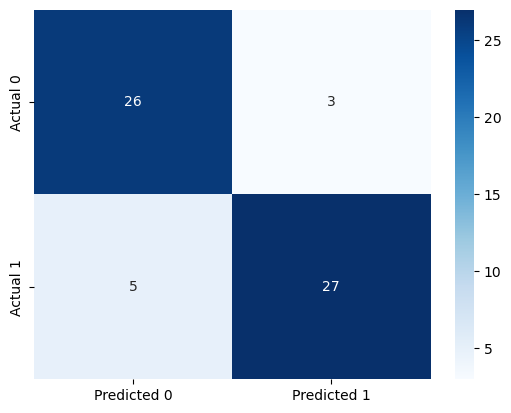

In [9]:
# 0= less chance of heart attack 1= more chance of heart attack
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

